In [1]:
import re
import matplotlib.pyplot as plt
import numpy as np

def parse_training_losses(log_file_path):
    """
    Parse training losses from log file, excluding test losses.
    Returns batch numbers and loss values for each loss type.
    """
    batch_numbers = []
    intra_losses = []
    inter_losses = []
    causal_losses = []
    cosmoothing_losses = []
    
    # Pattern to match training loss lines (exclude "Test loss:")
    # Example: "Epoch 1/100, Batch 1/380 (btbank2_6), LR: 0.000030, Loss: 0.9294 (intra: 0.9294),"
    loss_pattern = r'Epoch \d+/\d+, Batch (\d+)/\d+.*?Loss: ([\d.]+) \(([^)]+)\)'
    
    batch_num = 0
    with open(log_file_path, 'r') as f:
        for line in f:
            # Skip test loss lines
            if "Test loss:" in line:
                continue
                
            match = re.search(loss_pattern, line)
            if match:
                batch_num += 1
                total_loss = float(match.group(2))
                loss_details = match.group(3)
                
                # Parse individual loss types from the details
                # Examples: "intra: 0.9294", "causal: 0.9418", etc.
                intra = inter = causal = cosmoothing = 0.0
                
                if "intra:" in loss_details:
                    intra_match = re.search(r'intra: ([\d.]+)', loss_details)
                    if intra_match:
                        intra = float(intra_match.group(1))
                
                if "inter:" in loss_details:
                    inter_match = re.search(r'inter: ([\d.]+)', loss_details)
                    if inter_match:
                        inter = float(inter_match.group(1))
                
                if "causal:" in loss_details:
                    causal_match = re.search(r'causal: ([\d.]+)', loss_details)
                    if causal_match:
                        causal = float(causal_match.group(1))
                
                if "cosmoothing:" in loss_details:
                    cosmoothing_match = re.search(r'cosmoothing: ([\d.]+)', loss_details)
                    if cosmoothing_match:
                        cosmoothing = float(cosmoothing_match.group(1))
                
                batch_numbers.append(batch_num)
                intra_losses.append(intra)
                inter_losses.append(inter)
                causal_losses.append(causal)
                cosmoothing_losses.append(cosmoothing)
    
    return batch_numbers, intra_losses, inter_losses, causal_losses, cosmoothing_losses

# Load and parse the log file
log_file = '/om2/user/zaho/bfm/runs/logs/42975367_1.err'
batch_nums, intra, inter, causal, cosmoothing = parse_training_losses(log_file)

print(f"Parsed {len(batch_nums)} training batches")
print(f"First 5 batch numbers: {batch_nums[:5]}")
print(f"First 5 intra losses: {intra[:5]}")
print(f"First 5 inter losses: {inter[:5]}")
print(f"First 5 causal losses: {causal[:5]}")
print(f"First 5 cosmoothing losses: {cosmoothing[:5]}")


Parsed 21384 training batches
First 5 batch numbers: [1, 2, 3, 4, 5]
First 5 intra losses: [0.9294, 0.0, 0.0, 0.0, 0.9304]
First 5 inter losses: [0.0, 0.0, 0.0, 0.0, 0.0]
First 5 causal losses: [0.0, 0.9418, 0.9416, 0.9428, 0.0]
First 5 cosmoothing losses: [0.0, 0.0, 0.0, 0.0, 0.0]


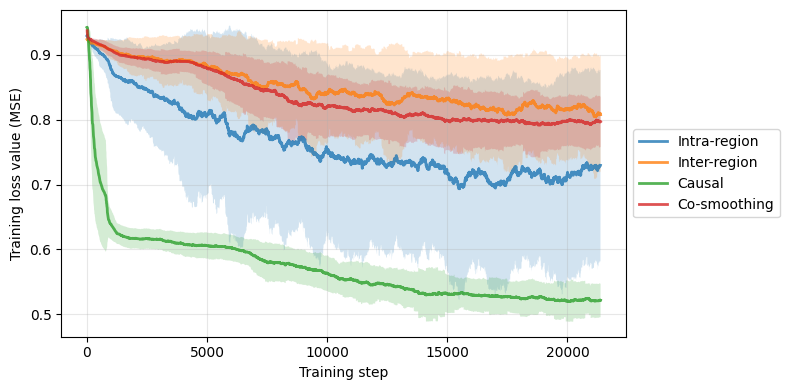

In [3]:
import numpy as np

def compute_running_average_and_std(values, window_size):
    """Compute running average and standard deviation"""
    if len(values) < window_size:
        return values, [0] * len(values)
    
    running_avg = []
    running_std = []
    
    for i in range(len(values)):
        start_idx = max(0, i - window_size + 1)
        end_idx = i + 1
        window_values = values[start_idx:end_idx]
        
        running_avg.append(np.mean(window_values))
        running_std.append(np.std(window_values))
    
    return running_avg, running_std

# Create the plot with 4 separate lines for each loss type
plt.figure(figsize=(8, 4))
n_running_average = 200

# Plot each loss type as a separate line with running average and std, but only plot non-zero values
if any(loss > 0 for loss in intra):
    intra_batches = [b for b, loss in zip(batch_nums, intra) if loss > 0]
    intra_values = [loss for loss in intra if loss > 0]
    intra_avg, intra_std = compute_running_average_and_std(intra_values, n_running_average)
    plt.plot(intra_batches, intra_avg, label='Intra-region', alpha=0.8, linewidth=2)
    plt.fill_between(intra_batches, 
                     np.array(intra_avg) - np.array(intra_std), 
                     np.array(intra_avg) + np.array(intra_std), 
                     alpha=0.2)

if any(loss > 0 for loss in inter):
    inter_batches = [b for b, loss in zip(batch_nums, inter) if loss > 0]
    inter_values = [loss for loss in inter if loss > 0]
    inter_avg, inter_std = compute_running_average_and_std(inter_values, n_running_average)
    plt.plot(inter_batches, inter_avg, label='Inter-region', alpha=0.8, linewidth=2)
    plt.fill_between(inter_batches, 
                     np.array(inter_avg) - np.array(inter_std), 
                     np.array(inter_avg) + np.array(inter_std), 
                     alpha=0.2)

if any(loss > 0 for loss in causal):
    causal_batches = [b for b, loss in zip(batch_nums, causal) if loss > 0]
    causal_values = [loss for loss in causal if loss > 0]
    causal_avg, causal_std = compute_running_average_and_std(causal_values, n_running_average)
    plt.plot(causal_batches, causal_avg, label='Causal', alpha=0.8, linewidth=2)
    plt.fill_between(causal_batches, 
                     np.array(causal_avg) - np.array(causal_std), 
                     np.array(causal_avg) + np.array(causal_std), 
                     alpha=0.2)

if any(loss > 0 for loss in cosmoothing):
    cosmoothing_batches = [b for b, loss in zip(batch_nums, cosmoothing) if loss > 0]
    cosmoothing_values = [loss for loss in cosmoothing if loss > 0]
    cosmoothing_avg, cosmoothing_std = compute_running_average_and_std(cosmoothing_values, n_running_average)
    plt.plot(cosmoothing_batches, cosmoothing_avg, label='Co-smoothing', alpha=0.8, linewidth=2)
    plt.fill_between(cosmoothing_batches, 
                     np.array(cosmoothing_avg) - np.array(cosmoothing_std), 
                     np.array(cosmoothing_avg) + np.array(cosmoothing_std), 
                     alpha=0.2)

plt.xlabel('Training step')
plt.ylabel('Training loss value (MSE)')
# plt.title(f'Training Losses Over Batches (Running Average n={n_running_average}) - 42975367_1.err')
plt.legend(bbox_to_anchor=(1, 0.5), loc='center left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
